# Example of usage of waveguide code

First we import a geometry (either gmsh or ngsolve based) along with the labels of its boundary regions

In [1]:
R = 2.
H = 1.

NGSOLVE = True

lc = 0.2

# if NGSOLVE:
#     from cases.waveguide.ngsolve_geometries import Empty, WaveguideRegions
#     mesh = Empty(R=R, H=H, verbosity=0, lc=lc)
# else:
#     from cases.waveguide.gmsh_geometries import Empty, WaveguideRegions
#     mesh = Empty(R=R, H=H, verbose=True, lc=lc)


In [2]:
from cases.waveguide.base import CleanWaveguide

waveguide = CleanWaveguide(R=R, H=H, lc=lc)

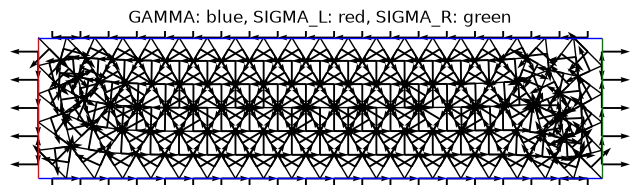

In [3]:
waveguide.plot()

In [4]:
list(waveguide.mesh.boundary_regions)

[<BoundaryRegions.GAMMA: 'Gamma'>,
 <BoundaryRegions.SIGMA_L: 'Sigma_L'>,
 <BoundaryRegions.SIGMA_R: 'Sigma_R'>]

To that regions we can apply different boundary conditions. In our case we will set a radianting boundary condition both in $\Sigma_L$ and $\Sigma_R$, and a _soundhard_ boundary condition at $\Gamma$.

The boundary conditions are just a dictionary:

In [5]:
from trefftz.dg.boundary_conditions import SoundHardBC, NtDBC

In [6]:
from cases.waveguide.NeumannToDirichlet import Mode, PropagationDirection
k = 8.0
t = 2
mode = Mode(k, H, t, direction=PropagationDirection.RIGHT)
boundary_conditions = {waveguide.mesh.boundary_regions.GAMMA: SoundHardBC(),
                       waveguide.mesh.boundary_regions.SIGMA_L: NtDBC(truncating_radius=R, data=1.), #I need to refine this, right now "data" is nonsense
                       waveguide.mesh.boundary_regions.SIGMA_R: NtDBC(truncating_radius=R, data=1.)}

Each boundary condition corresponds to a given kernel (this perhaps should be a default). There are general kernels for _soundhard_ or _transmission_ kernels:

In [7]:
from trefftz.dg.serial_fluxes import UltraWeakFlux, NeumannFlux


as well as specific ones (for the waveguide):

In [8]:
from cases.waveguide.serial_fluxes import NtDLocal, NtDNonLocal

Now the numerics (the configuration of kernels) is almost a dictionary:

In [9]:
from trefftz.dg.assemblers import SerialNumerics

NtD_modes = 10

numerics = SerialNumerics(interior_kernel=UltraWeakFlux(a=0.5, b=0.5),
                          local_boundary_kernels={SoundHardBC: NeumannFlux(d_1=0.5),
                                                  NtDBC: NtDLocal(d_2=0.5, NtD_modes=NtD_modes, data=mode)},
                          nonlocal_boundary_kernels={NtDBC: NtDNonLocal(H=H, d_2=0.5, NtD_modes=NtD_modes, data=mode)})

# numerics = SerialNumerics(interior_kernel=UltraWeakFlux(a=0.5, b=0.5),
#                           local_boundary_kernels={SoundHardBC: NeumannFlux(d_1=0.5),
#                                                   NtDBC: NtDLocal(R=R, d_2=0.5, data=mode)},
#                           nonlocal_boundary_kernels={})

We should also choose a local basis

In [88]:
from trefftz.dg.basis import LinearlySpacedBasis
N_theta = 15
basis = LinearlySpacedBasis(N_elements=waveguide.mesh.n_triangles, k=k, N_theta=N_theta)
basis.N_DOF

3630

and an assembler:

In [89]:
from trefftz.dg.assemblers import SerialAssembler

assembler = SerialAssembler(mesh=waveguide.mesh, boundary_conditions=boundary_conditions, numerics=numerics, basis=basis)

so we can set the problem:

In [90]:
from trefftz.problem import Problem
P = Problem(mesh=waveguide.mesh, wavenumber=k, basis=basis, boundary_conditions=boundary_conditions, assembler=assembler, direct_solver=True)  #, numerics=numerics)

In [91]:
A = P.assemble_LHS()

Interior: 100%|██████████| 338/338 [00:16<00:00, 21.02edge/s]


assembling local operators
region: Gamma


100%|██████████| 40/40 [00:00<00:00, 156.85edge/s]


region: Sigma_L


100%|██████████| 5/5 [00:00<00:00, 176.76edge/s]


region: Sigma_R


100%|██████████| 5/5 [00:00<00:00, 177.93edge/s]


assembling non-local operators


NtD, Sigma_R: 100%|██████████| 5/5 [00:13<00:00,  2.69s/edge]


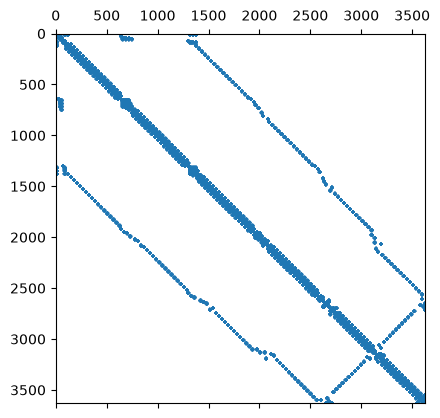

In [92]:
import matplotlib.pyplot as plt 
plt.spy(A, markersize=0.1)

In [93]:
assembler._regions_RHS_term

[<BoundaryRegions.SIGMA_L: 'Sigma_L'>, <BoundaryRegions.SIGMA_R: 'Sigma_R'>]

In [94]:
b = P.assemble_RHS()

region=<BoundaryRegions.SIGMA_L: 'Sigma_L'>, value=np.complex128(-1.0392897249540556-5.491575061834774j)
region=<BoundaryRegions.SIGMA_L: 'Sigma_L'>, value=np.complex128(5.063244156414119+0.8297481348527707j)
region=<BoundaryRegions.SIGMA_L: 'Sigma_L'>, value=np.complex128(3.9219801689221505+0.27242405335630615j)
region=<BoundaryRegions.SIGMA_L: 'Sigma_L'>, value=np.complex128(1.3995322073819783-1.8930030812971634j)
region=<BoundaryRegions.SIGMA_L: 'Sigma_L'>, value=np.complex128(-0.010863406659730783-0.6860160255205006j)
region=<BoundaryRegions.SIGMA_L: 'Sigma_L'>, value=np.complex128(-0.7039691804546984+0.5790073623178933j)
region=<BoundaryRegions.SIGMA_L: 'Sigma_L'>, value=np.complex128(2.0313065241964323-0.9836931126768979j)
region=<BoundaryRegions.SIGMA_L: 'Sigma_L'>, value=np.complex128(2.8480870955854583-1.1167452375126894j)
region=<BoundaryRegions.SIGMA_L: 'Sigma_L'>, value=np.complex128(-2.728500473041043+1.3834757671034557j)
region=<BoundaryRegions.SIGMA_L: 'Sigma_L'>, value=

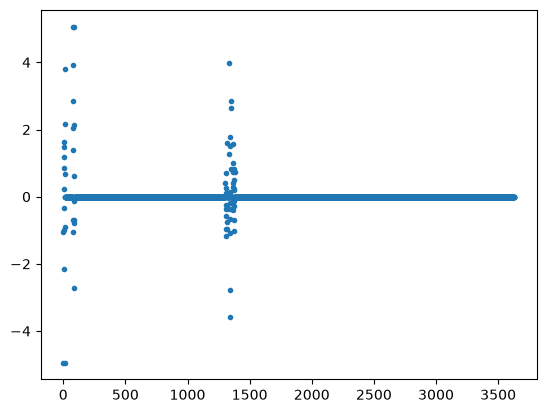

In [95]:
plt.plot(b.real,'.')

In [96]:
import numpy as np
np.count_nonzero(b)/N_theta

np.float64(5.0)

In [97]:
P.solve()

In [98]:
P.u_h.coefficients.reshape((-1, N_theta))

array([[  -8.51976312   -8.71635705j,   -3.7918215   -12.41300603j,
         -13.75065528   +6.82661038j, ...,   10.30279018  -12.00530857j,
           8.00107987  +14.54349439j,   10.40813285   +9.10134373j],
       [ 973.71477906 -146.78806963j, -815.10523335 -827.84433983j,
        -595.74176968-1139.6660376j , ..., -726.29460036 +685.91763274j,
         809.37030767 -284.99717375j,   86.53811133 -840.31756523j],
       [ -12.14624453  +14.63646492j,    2.68402124  -16.75028679j,
         -17.15116605  -18.1889397j , ...,   42.63570682  +62.0322249j ,
         -30.80193791  -38.16968201j,  -15.35799633  +25.20100169j],
       ...,
       [ 253.63576574 -311.08605489j,   72.96116195 -530.28562836j,
        -649.04827897 +246.38623826j, ...,  558.73988723 -219.28753972j,
         450.84975842  -79.60281515j, -270.73313664 -248.33219359j],
       [  62.38425123 +140.11951778j,   -6.20218929 +173.80481049j,
         190.87918013  +64.42808728j, ...,   97.71259446 -155.58229555j,
       

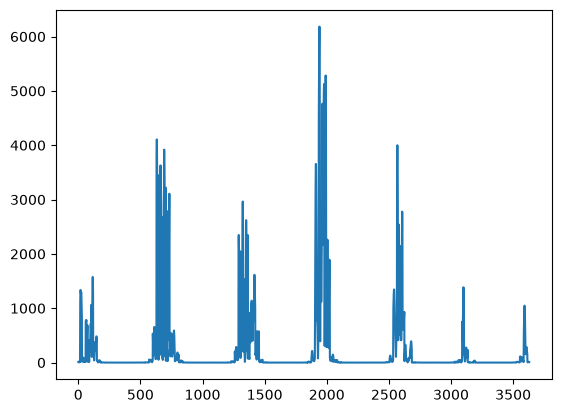

In [99]:
plt.plot(np.abs(P.u_h.coefficients))

In [100]:
import numpy as np
N = 200
x = np.linspace(-R, R, N)
y = np.linspace(0., H, int(N*H/R))
X, Y = np.meshgrid(x, y)
Z = P.u_h(X.ravel(), Y.ravel()).reshape(X.shape)

(0.0, 1.0)

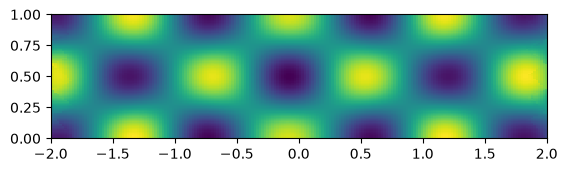

In [101]:
import matplotlib.pyplot as plt 
plt.pcolormesh(X, Y, Z.real)
plt.axis('square')
plt.xlim([-R, R])
plt.ylim([0., H])

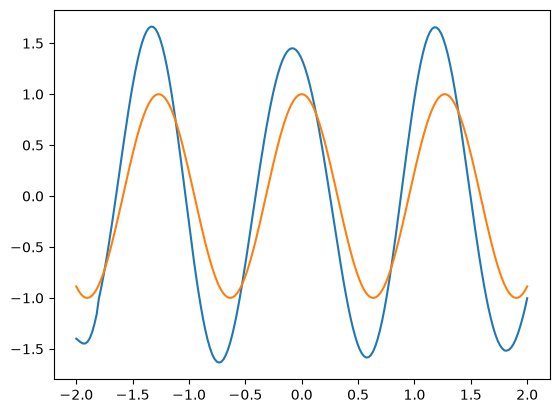

In [102]:
plt.plot(x,Z[0,:].real)
plt.plot(x,np.exp(1j*np.lib.scimath.sqrt(k**2 - (t*np.pi/H)**2)*x).real)

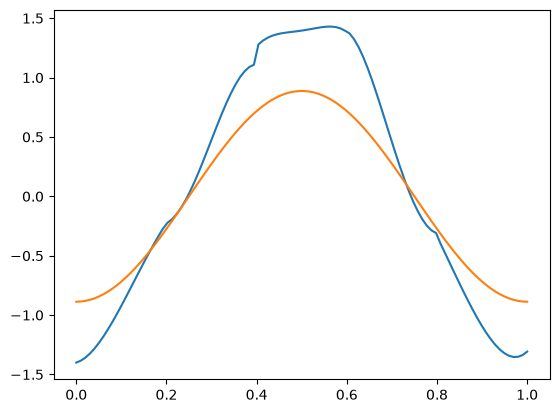

In [103]:
plt.plot(y,Z[:,0].real)
plt.plot(y,np.exp(-1j*np.lib.scimath.sqrt(k**2 - (t*np.pi/H)**2)*R).real*np.cos(t*np.pi/H*y))